# Probability of Improvement

This section describes another approach for performing balanced exploration and exploitation. Specifically, probability of improvement (PI) is used as the acquisition function. The auxiliary optimization problem is written as:

$$
    \max_{\mathbf{x} \in \Omega} \text{ PI}(\mathbf{x}),
$$

where PI is written as

$$
\begin{aligned}
    \text{PI}(\mathbf{x}) & = P \Big[ \hat{f}(\mathbf{x}) \leq f^* \Big ] \\ 
    & = P \Bigg [ \frac{\hat{f}(\mathbf{x}) - \mu(\mathbf{x}) }{\sigma(\mathbf{x})} \leq \frac{f^* - \mu(\mathbf{x}) }{\sigma(\mathbf{x})} \Bigg ] \\ 
    & = P \Bigg [ Z \leq \frac{f^* - \mu(\mathbf{x}) }{\sigma(\mathbf{x})} \Bigg ], \text{ where } Z = \frac{\hat{f}(\mathbf{x}) - \mu(\mathbf{x}) }{\sigma(\mathbf{x})} \sim \mathcal{N}(0,1) \\ 
    & = \Phi \Bigg( \frac{f^* - \mu(\mathbf{x}) }{\sigma(\mathbf{x})} \Bigg) \\
\end{aligned}
$$

where $\Phi$ is the cumulative distribution function of the standard normal distribution, $f^*$ is the current best value, and $\mu(\mathbf{x})$ and $\sigma(\mathbf{x})$ are model prediction and uncertainty in prediction (standard deviation) from surrogate model, respectively. Note that $\hat{f}$ follows a normal distribution since it is modeled using a GP. So, PI measures the probability that prediction at a given point $\mathbf{x}$ beats the current best value. Note that the acquisition function optimization is a maximization problem.

Below code imports required packages and defines modified branin function:

In [1]:
import numpy as np
import torch
from pyDOE3 import lhs
import matplotlib.pyplot as plt
from scipy.stats import norm as normal
from scimlstudio.models import SingleOutputGP
from scimlstudio.utils import Standardize, Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood

from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.optimize import minimize
from pymoo.config import Config
Config.warnings['not_compiled'] = False

# Defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float64
}

def modified_branin(x: np.ndarray) -> np.ndarray:
    """
        Function for computing modified branin function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    a = 1.
    b = 5.1 / (4.*np.pi**2)
    c = 5. / np.pi
    r = 6.
    s = 10.
    t = 1. / (8.*np.pi)

    y = a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s + 5*x1

    return np.expand_dims(y,-1)

lb = np.array([-5., 0.])
ub = np.array([10., 15.])

/home/pavan/miniconda3/envs/sm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Below code block defines `pymoo` problem class and initializes differential evolution algorithm:

In [2]:
class ProbabilityOfImprovement(Problem):

    def __init__(self, gp, lb: np.ndarray, ub: np.ndarray, fbest: float):
        """
            Class for defining auxiliary optimization problem that uses
            probability of improvment as the acquisition function
        """

        # initialize parent class
        super().__init__(n_var=lb.shape[0], n_obj=1, n_constr=0, xl=lb, xu=ub)

        # store variables
        self.gp = gp
        self.fbest = fbest

    def _evaluate(self, x, out, *args, **kwargs):

        # convert to torch tensor
        x = torch.from_numpy(x).to(self.gp.x_train)

        # get mean prediction
        y_mean, y_var = self.gp.predict(x)

        std_variable = (self.fbest - y_mean.numpy(force=True)) / y_var.numpy(force=True)**0.5

        # store the objective value as numpy array
        out["F"] = - normal.cdf(std_variable) # negating since pymoo minimizes

# Optimization algorithm
algorithm = DE(pop_size=15*lb.shape[0], F=0.9, CR=0.8, seed=1)

## BO loop

Below code implements BO loop with PI-based acquisition function. Four initial samples are used with a maximum function evaluation budget of 24. This implies that there will be 20 iterations of the loop. The initial samples are generated using latin hypercube sampling. A Gaussian process model is used to approximate the modified Branin function since it provides both point-prediction and uncertainty in prediction.

In [3]:
# variables
num_init = 4
max_evals = 24
num_evals = 0

# initial training data
x_train = lhs(lb.shape[0], samples=num_init, criterion='cm', iterations=100, seed=1)
x_train = lb + (ub - lb) * x_train
y_train = modified_branin(x_train)

# increment evals
num_evals += num_init

idx_best = np.argmin(y_train)
fbest = [y_train[idx_best]]
xbest = [x_train[idx_best]]

print("Current best before loop:")
print("x: {}".format(xbest[-1]))
print("f: {}".format(fbest[-1]))

print("\nLCB Loop:")

# loop
while num_evals < max_evals:

    print(f"\nIteration: {num_evals-num_init+1}")

    # GP
    gp = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(y_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp) # marginal log likelihood

    optimizer = torch.optim.Adam(gp.parameters(), lr=0.01) # optimizer

    # Training the model
    gp.fit(training_iterations=1000, mll=mll, optimizer=optimizer)

    # Find the minimum of surrogate model
    result = minimize(ProbabilityOfImprovement(gp, lb, ub, fbest[-1]), algorithm, verbose=False)

    # Computing true function value at infill point
    y_infill = modified_branin(result.X)

    print("New point (based on PI):")
    print("x: {}".format(result.X))
    print("f: {}".format(y_infill.item()))

    # Appending the the new point to the current data set
    x_train = np.vstack(( x_train, result.X.reshape(1,-1) ))
    y_train = np.vstack((y_train, y_infill))

    # increment evals
    num_evals += 1

    # Find current best point
    idx_best = np.argmin(y_train)
    fbest.append(y_train[idx_best])
    xbest.append(x_train[idx_best])
    
    print("Current best:")
    print("x: {}".format(xbest[-1]))
    print("f: {}".format(fbest[-1]))

fbest = np.array(fbest)
xbest = np.array(xbest)

Current best before loop:
x: [-3.125  5.625]
f: [28.46841701]

LCB Loop:

Iteration: 1
New point (based on PI):
x: [-1.28222835  3.92637771]
f: 25.042151867514193
Current best:
x: [-1.28222835  3.92637771]
f: [25.04215187]

Iteration: 2
New point (based on PI):
x: [-1.90176274  2.29764221]
f: 49.15806245998584
Current best:
x: [-1.28222835  3.92637771]
f: [25.04215187]

Iteration: 3
New point (based on PI):
x: [0.25633158 4.293026  ]
f: 22.279586942485313
Current best:
x: [0.25633158 4.293026  ]
f: [22.27958694]

Iteration: 4
New point (based on PI):
x: [1.25155459 4.05730406]
f: 19.294815602192276
Current best:
x: [1.25155459 4.05730406]
f: [19.2948156]

Iteration: 5
New point (based on PI):
x: [2.63519033 3.59170684]
f: 15.568659784675463
Current best:
x: [2.63519033 3.59170684]
f: [15.56865978]

Iteration: 6
New point (based on PI):
x: [2.94464332 3.46556585]
f: 16.371677019184148
Current best:
x: [2.63519033 3.59170684]
f: [15.56865978]

Iteration: 7
New point (based on PI):
x: [2.

/home/pavan/miniconda3/envs/sm/lib/python3.12/site-packages/gpytorch/distributions/multivariate_normal.py:376: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


New point (based on PI):
x: [2.4924227  3.05267764]
f: 14.860284661117507
Current best:
x: [2.4924227  3.05267764]
f: [14.86028466]

Iteration: 10
New point (based on PI):
x: [2.48394706 2.99381697]
f: 14.84282324185292
Current best:
x: [2.48394706 2.99381697]
f: [14.84282324]

Iteration: 11
New point (based on PI):
x: [-1.80390134  6.23969093]
f: 8.075167643248076
Current best:
x: [-1.80390134  6.23969093]
f: [8.07516764]

Iteration: 12
New point (based on PI):
x: [-1.72050655  6.89526437]
f: 4.917752846444749
Current best:
x: [-1.72050655  6.89526437]
f: [4.91775285]

Iteration: 13
New point (based on PI):
x: [-1.6961256   7.55479133]
f: 2.6183199785326057
Current best:
x: [-1.6961256   7.55479133]
f: [2.61831998]

Iteration: 14
New point (based on PI):
x: [-1.71164068  8.36700542]
f: 0.635010055854595
Current best:
x: [-1.71164068  8.36700542]
f: [0.63501006]

Iteration: 15
New point (based on PI):
x: [-1.73471657  8.78699237]
f: -0.10901479871209041
Current best:
x: [-1.73471657  8

Below code plots the evolution of optimum point with respect to number of iterations:

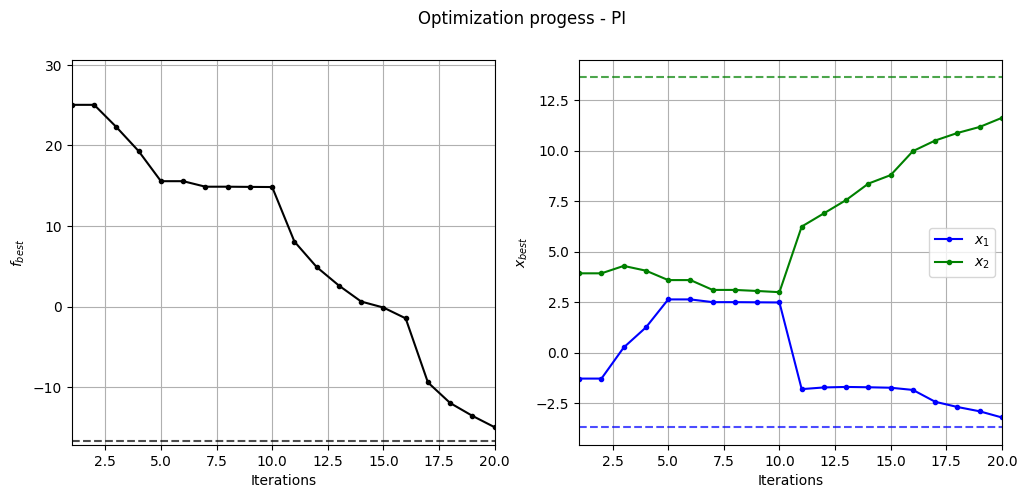

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fbest, ".k-")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("$f_{best}$")
ax[0].axhline(y=-16.64, c="k", linestyle="--", alpha=0.7)
ax[0].set_xlim(left=1, right=fbest.shape[0]-1)
ax[0].grid()

ax[1].plot(xbest[:,0], ".b-", label="$x_1$")
ax[1].plot(xbest[:,1], ".g-", label="$x_2$")
ax[1].axhline(y=-3.689, c="b", linestyle="--", alpha=0.7)
ax[1].axhline(y=13.630, c="g", linestyle="--", alpha=0.7)
ax[1].set_xlim(left=1, right=xbest.shape[0]-1)
ax[1].set_ylabel("$x_{best}$")
ax[1].set_xlabel("Iterations")
ax[1].legend()
ax[1].grid()

_ = plt.suptitle("Optimization progess - PI")

Below code plots the infill points added during the optimization process:

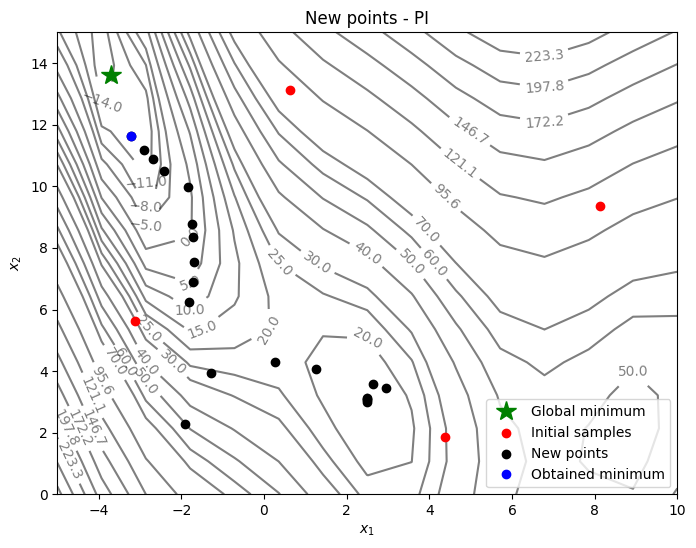

In [5]:
num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(40, 60, 3)))
levels = np.concatenate((levels, np.linspace(70, 300, 10)))

fig, ax = plt.subplots(figsize=(8,6))

# Contours and global opt
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid', alpha=0.5, zorder=-10)
ax.clabel(CS, inline=1)
ax.plot(-3.689, 13.630, 'g*', markersize=15, label="Global minimum")

# Points
ax.scatter(x_train[0:num_init,0], x_train[0:num_init,1], c="red", label='Initial samples')
ax.scatter(x_train[num_init:,0], x_train[num_init:,1], c="black", label='New points')
ax.plot(xbest[-1][0], xbest[-1][1], 'bo', label="Obtained minimum")

# asthetics
ax.legend()
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
_ = ax.set_title("New points - PI")

Based on the infills, PI seems to be slightly more biased towards adding points closer to the minimum value in the dataset - less exploration and more exploitation - and there is no way to control that through the criteria itself. As a result, PI-based method lingers around one of the local optimum and requires more iterations to reach global optimum. As discussed in the lecture, PI provides only a probability value and doesn't quantify the amount of improvement. We need a better acquisition function that can quantify the improvement.

> __*NOTE*__: Due to randomness in differential evolution, results may vary slightly between runs. So, it is recommended to run the code multiple times to see average behavior.